### Load Data + Light Pre-processing

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [171]:
import joblib

# Load train/test data
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# Load encoders
scaler = joblib.load("scaler.joblib")
target_encoder = joblib.load("target_encoder.joblib")

### Logistic Regression

In [172]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial'
)

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Accuracy: {lr_acc :.3f}")

c:\Users\honwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Accuracy: 0.106


The baseline Logistic Regression model achieved an accuracy of approximately 10.6%. Since the dataset contains multiple balanced outcome classes, the result suggests that Logistic Regression may have difficulty capturing complex relationships within the data.

In [173]:
param_grid = {
    'C':[0.1,1,10],
    'solver':['lbfgs','saga']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, multi_class='multinomial'),
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print(f"Best Parameters: {grid_lr.best_params_}")
print(f"Best Score: {grid_lr.best_score_}")

c:\Users\honwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Score: 0.099575


The tuned Logistic Regression model achieved an accuracy of approximately 9.95%, which approximates to the baseline result (10.6%). This indicates that changing model parameters did not significantly improve performance. Therefore, Logistic Regression may not be sufficient to capture the complex patterns in this multiclass dataset.

### K Nearest Neighbours

In [174]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_acc}")

KNN Accuracy: 0.1009


The baseline KNN model achieved an accuracy of approximately 10.09%, similar to but slightly worse than Logistic Regression.

In [175]:
param_grid = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print(f"Best Parameters: {grid_knn.best_params_}")
print(f"Best Score: {grid_knn.best_score_}")

Best Parameters: {'n_neighbors': 9, 'weights': 'uniform'}
Best Score: 0.10087499999999999


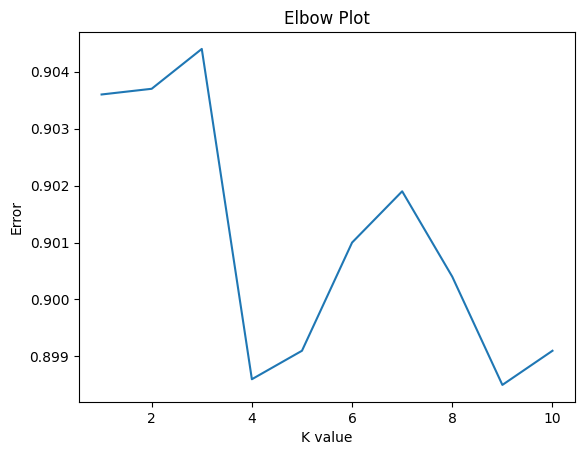

In [176]:
# Elbow plot

error=[]

for i in range(1,11):
    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)
    error.append(1-score)

plt.plot(range(1,11), error)
plt.title('Elbow Plot')
plt.xlabel("K value")
plt.ylabel("Error")
plt.show()

Elbow plot shows minimum points at k=4 and k=9, reflecting best k in `grid_knn.best_params`, though it is worth noting that tuning hyperparameters does not affect performance (both accuracy score = 10.9%).

### Support Vector Machine (SVM)

In [177]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

svm = LinearSVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

In [178]:
print(svm_acc)
print(classification_report(y_test, svm_pred))

0.1043
              precision    recall  f1-score   support

           0       0.10      0.11      0.11      1010
           1       0.11      0.11      0.11      1005
           2       0.12      0.11      0.11      1004
           3       0.11      0.08      0.09       984
           4       0.10      0.08      0.09       992
           5       0.10      0.13      0.11      1016
           6       0.10      0.13      0.11       998
           7       0.12      0.06      0.08       997
           8       0.11      0.15      0.13      1022
           9       0.09      0.08      0.08       972

    accuracy                           0.10     10000
   macro avg       0.10      0.10      0.10     10000
weighted avg       0.10      0.10      0.10     10000



In [179]:
df = pd.read_csv('dating_app_behavior_dataset_extended1.csv')
outcome_map = {i: df['match_outcome'].unique().tolist()[i] for _, i in enumerate(svm.classes_)}

Classification report shows similar precision, recall and f1 score for all features. Accuracy of 10.43% makes SVM a weak predictive model just as logistic regression and KNN (difference in their accuracies are minute)

In [180]:
for i, class_name in enumerate(svm.classes_):
    coef_df = pd.DataFrame({
        "feature": X_train.columns,
        "coef": svm.coef_[i]
    })
    coef_df['abs_coef'] = coef_df['coef'].abs()
    coef_df = coef_df.sort_values(by=['abs_coef'], ascending=False)

    print(outcome_map[class_name])
    print(coef_df.head(5))
    print()

Mutual Match
                          feature      coef  abs_coef
20    sexual_orientation_Bisexual -0.020565  0.020565
43             zodiac_sign_Pisces -0.018359  0.018359
36      swipe_time_of_day_Morning  0.016636  0.016636
35   swipe_time_of_day_Late Night  0.014519  0.014519
21  sexual_orientation_Demisexual  0.014215  0.014215

Chat Ignored
                     feature      coef  abs_coef
17         gender_Non-binary -0.027560  0.027560
19        gender_Transgender -0.025972  0.025972
52            body_type_Slim -0.025522  0.025522
18  gender_Prefer Not to Say -0.024450  0.024450
46        zodiac_sign_Taurus -0.021906  0.021906

Date Happened
                        feature      coef  abs_coef
39        zodiac_sign_Capricorn -0.026523  0.026523
26  sexual_orientation_Straight  0.021335  0.021335
38           zodiac_sign_Cancer  0.021016  0.021016
37            zodiac_sign_Aries  0.020958  0.020958
25     sexual_orientation_Queer  0.018947  0.018947

No Action
                 

In [181]:
# Compute global coef
importance = np.mean(np.abs(svm.coef_), axis=0)

global_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importance
    }).sort_values(by="importance", ascending=False)

print(global_importance.head(20))

                          feature  importance
41                zodiac_sign_Leo    0.017661
43             zodiac_sign_Pisces    0.016468
44        zodiac_sign_Sagittarius    0.016245
46             zodiac_sign_Taurus    0.016232
38             zodiac_sign_Cancer    0.014857
45            zodiac_sign_Scorpio    0.013573
39          zodiac_sign_Capricorn    0.013240
17              gender_Non-binary    0.013081
40             zodiac_sign_Gemini    0.012754
26    sexual_orientation_Straight    0.012613
37              zodiac_sign_Aries    0.012482
22         sexual_orientation_Gay    0.012476
20    sexual_orientation_Bisexual    0.010999
50             body_type_Muscular    0.010872
30         location_type_Suburban    0.010798
19             gender_Transgender    0.010701
21  sexual_orientation_Demisexual    0.010386
42              zodiac_sign_Libra    0.010063
47              zodiac_sign_Virgo    0.009933
25       sexual_orientation_Queer    0.009785


There is no single identifiable feature that gives a clear signal for predicting a certain outcome and appear random. Accuracy of 10.45% is indicative of a predictive ability similar to random guessing.

In [182]:
# Tune hyperparameters

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(f"Best macro f1 score: {grid.best_score_:.3f}")

{'C': 0.1}
Best macro f1 score: 0.099


In [183]:
grid_cv_pred = grid.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, grid_cv_pred)}")

SVM Accuracy: 0.1041


In [184]:
print(list(set(y_train.tolist())))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Features do not separate classes of outcomes well with `f1_macro = 0.099`, predicated by a weak, unchanged `accuracy=0.104`. Hyperparameter tuning produces insignificant improvements to the model.

### XG Boost

In [185]:
import xgboost as xgb

params = {
'objective': 'multi:softprob',
'num_class': 10,
'tree_method': 'hist',
'max_depth': 6,
'learning_rate': 0.1
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

model = xgb.train(params, dtrain, num_boost_round=100)

# Array of probabilities for each outcome (index of max is the predicted class)
probs = model.predict(dtest)
xgb_pred = probs.argmax(axis=1)

print(f"XGB Accuracy: {accuracy_score(y_test, xgb_pred)}")

XGB Accuracy: 0.1021


`accuracy=0.103` suggests marginal difference between its performance and that of SVM (`accuracy=0.104`). Minimal signal has been captured by the model.

In [186]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    probs,
    multi_class='ovr',  # one-vs-rest
    average='macro'
)

print("Macro ROC-AUC:", auc)

Macro ROC-AUC: 0.49756731825741596


ROC curve is a function of true positive rate (TPR) against false positive rate (FPR). 

A score of ~0.5 indicates the model performs no better than random guessing. 

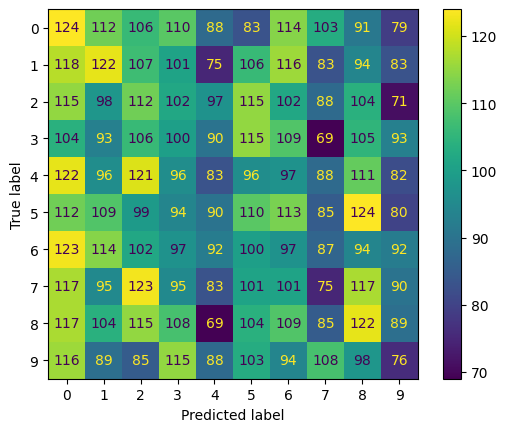

In [187]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = probs.argmax(axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Confusion matrix shows near perfect distribution of each class prediction. 

Every class is almost as likely to be predicted as the other. 

In [188]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=10,
    eval_metric='mlogloss',
    tree_method='hist',
    n_estimators=100,
    random_state=42
)

param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters: {search.best_params_}")
print(search.best_score_)

Best parameters: {search.best_params_}
0.10197499387762181


Tuning hyperparameters using grid search does not improve model accuracy (10.28% $\approx$ 10.19%). However, it suggested a more optimal `max_depth` (3<6) and `subsample` (0.8<1.0), that may reduce overall training time.